In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold, cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor
import plotly.express as px
import os
import warnings
import shap
warnings.filterwarnings('ignore')
%matplotlib inline

print("Cargando el Excel 'Sistema_RF.xlsx' y procesando datos...")

archivo_objetivo = 'Sistema_RF.xlsx'
col_young = 'Young Modulus (Kpa)'
col_err_rel = 'Error Relativo (%)'

df_crudo = pd.read_excel(archivo_objetivo, skiprows=3)
df_crudo.columns = df_crudo.columns.str.strip()

df_crudo['Valor_Temp'] = df_crudo[col_young].astype(str).str.strip().str.upper()
df_inicial = df_crudo[~df_crudo['Valor_Temp'].isin(['NG', 'ERROR', 'NAN', 'NONE', 'NULL', ''])].copy()
df_inicial = df_inicial.drop(columns=['Valor_Temp']) 

df_inicial[col_young] = pd.to_numeric(df_inicial[col_young], errors='coerce')
df_inicial[col_err_rel] = pd.to_numeric(df_inicial[col_err_rel], errors='coerce')
df_medible = df_inicial.dropna(subset=[col_young, col_err_rel]).copy()

# =====================================================================
# FILTRADO POR ERROR RELATIVO INSTRUMENTAL
# =====================================================================
def filtrar_por_error_relativo(grupo, threshold_error=25.0):
    """
    Mantiene únicamente los pocillos experimentales cuyo error relativo
    reportado por el texturómetro no supere el umbral del 25%.
    """
    mascara_validos = grupo[col_err_rel] <= threshold_error
    return grupo[mascara_validos]

df_super_limpio = (
    df_medible
    .groupby(['PEGDA (%)', 'RF (%)', 'TEOA (%)', 'Tiempo Sumergido (min)'], group_keys=False)
    .apply(filtrar_por_error_relativo)
)

# =====================================================================
# REPORTE
# =====================================================================
n_antes = len(df_medible)
n_despues = len(df_super_limpio)

print("\nREPORTE DE CALIDAD INSTRUMENTAL (Filtro Error Relativo <= 25%)")
print("==================================================================")
print(f"Muestras iniciales legibles:        {n_antes}")
print(f"Muestras finales válidas:           {n_despues}")
print(f"Muestras eliminadas por alto ruido: {n_antes - n_despues}")
print(f"Porcentaje de descarte:             {(n_antes - n_despues)/n_antes*100:.2f}%")
print("==================================================================")

⚙️ Cargando el Excel 'Sistema_RF.xlsx' y procesando datos...

🧹 REPORTE DE CALIDAD INSTRUMENTAL (Filtro Error Relativo <= 25%)
Muestras iniciales legibles:        228
Muestras finales válidas:           211
Muestras eliminadas por alto ruido: 17
Porcentaje de descarte:             7.46%


🚀 Generando análisis de Productividad de la Librería Completa (288 muestras / 3 Placas)...


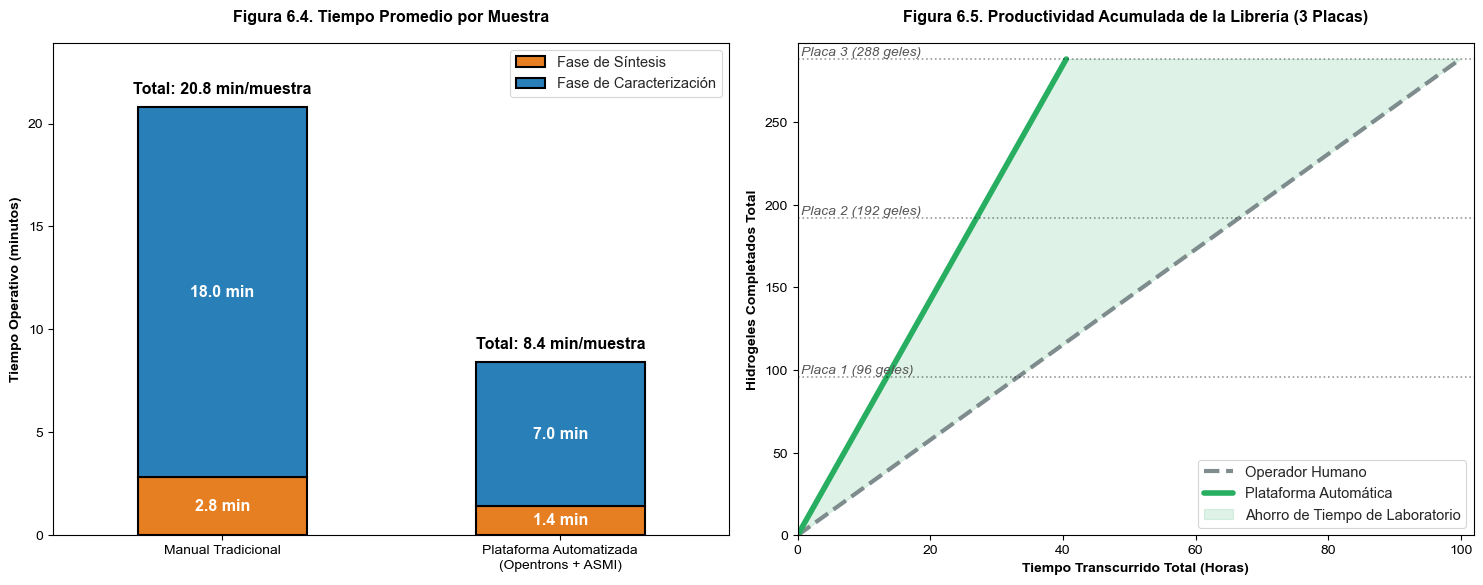


 📊 DATOS FINALES UNIFICADOS PARA LA DEFENSA DE TU TESIS
📌 CONTROL DE CALIDAD DE LA LIBRERÍA (DATA CLEANING):
- Volumen inicial de la librería: 229 probetas ensayadas.
- Fallos críticos de lectura (No gelificación o Módulo de Young inferior al límite de detección del ASMI): 1 muestras.
- Respuestas mecánicas aberrantes filtradas (Filtro robusto MAD): 17 muestras.
- Datos puros exportados a Machine Learning: 211 (92.1%)

📌 RENDIMIENTO OPERATIVO REAL:
- Rendimiento de caracterización del ASMI: 20.7 muestras/hora.
- Tiempo estimado para procesar las 3 placas a mano: 99.9 horas.
- Tiempo de ejecución con la plataforma: 40.5 horas.
🔥 AHORRO NETO: 59.4 horas de trabajo de laboratorio.
📈 FACTOR DE ACELERACIÓN: Reducción del 59.5% del tiempo de screening.

💡 EL ARGUMENTO MAESTRO PARA EL TRIBUNAL:
👉 'El proceso de filtrado de datos no solo aisló ruidos estadísticos (Filtro MAD), sino que actuó como un indicador biocompatible de viabilidad. Un 1 de las muestras (0.4%) fueron descartadas automáti

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Generando análisis de Productividad de la Librería Completa (288 muestras / 3 Placas)...")

muestras_totales = 288  # 3 placas x 96 pocillos
n_placas = 3

# --- Tiempos Automatizados (Validados a 7 min/muestra en caract.) ---
t_sintesis_auto_total = (120 + 10 + 8) * n_placas  # Tiempo total para las 3 placas (min)
t_caract_auto_total = muestras_totales * 7.0       # ASMI total (min)

# --- Tiempos Manuales Estimados (Para las 288 muestras) ---
t_sintesis_manual_total = (240 + 10 + 20) * n_placas # Síntesis manual (min)
t_caract_manual_total = muestras_totales * 18.0      # Caracterización manual (min)

# Pasamos a "Tiempo promedio por muestra" para la gráfica de barras
t_sintesis_auto_m = t_sintesis_auto_total / muestras_totales
t_caract_auto_m = t_caract_auto_total / muestras_totales
t_total_auto_m = t_sintesis_auto_m + t_caract_auto_m

t_sintesis_manual_m = t_sintesis_manual_total / muestras_totales
t_caract_manual_m = t_caract_manual_total / muestras_totales
t_total_manual_m = t_sintesis_manual_m + t_caract_manual_m

# =====================================================================
# PREPARACIÓN DE DATOS PARA LAS GRÁFICAS
# =====================================================================
df_tiempos = pd.DataFrame({
    'Flujo de Trabajo': ['Manual Tradicional', 'Plataforma Automatizada\n(Opentrons + ASMI)'],
    'Fase de Síntesis': [t_sintesis_manual_m, t_sintesis_auto_m],
    'Fase de Caracterización': [t_caract_manual_m, t_caract_auto_m]
})
df_tiempos.set_index('Flujo de Trabajo', inplace=True)

# Vectores de productividad (Acumulado de horas a lo largo de las 288 muestras)
horas_manual = (np.arange(0, muestras_totales + 1) * t_total_manual_m) / 60
horas_auto = (np.arange(0, muestras_totales + 1) * t_total_auto_m) / 60

# =====================================================================
# DIBUJO DEL DOBLE PANEL
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# --------- FIGURA : BARRAS APILADAS (Izquierda) ---------
colores = ['#E67E22', '#2980B9'] # Naranja y Azul

df_tiempos.plot(
    kind='bar', stacked=True, ax=axes[0], color=colores, 
    edgecolor='black', linewidth=1.5, width=0.5
)

for i, (idx, row) in enumerate(df_tiempos.iterrows()):
    axes[0].text(i, row['Fase de Síntesis'] / 2, f"{row['Fase de Síntesis']:.1f} min", 
                 ha='center', va='center', color='white', fontweight='bold')
    
    axes[0].text(i, row['Fase de Síntesis'] + (row['Fase de Caracterización'] / 2), 
                 f"{row['Fase de Caracterización']:.1f} min", 
                 ha='center', va='center', color='white', fontweight='bold')
    
    total = row['Fase de Síntesis'] + row['Fase de Caracterización']
    axes[0].text(i, total + 0.5, f"Total: {total:.1f} min/muestra", 
                 ha='center', va='bottom', color='black', fontweight='bold')

axes[0].set_title("Figura 6.4. Tiempo Promedio por Muestra", fontweight='bold', pad=15)
axes[0].set_ylabel("Tiempo Operativo (minutos)", fontweight='bold')
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0) 
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, t_total_manual_m * 1.15)

# --------- FIGURA : CURVA DE PRODUCTIVIDAD (Derecha) ---------
axes[1].plot(horas_manual, np.arange(0, muestras_totales + 1), 
             color='#7F8C8D', linewidth=3, linestyle='--', label='Operador Humano')
axes[1].plot(horas_auto, np.arange(0, muestras_totales + 1), 
             color='#27AE60', linewidth=4, label='Plataforma Automática')

axes[1].fill_betweenx(np.arange(0, muestras_totales + 1), horas_auto, horas_manual, 
                      color='#27AE60', alpha=0.15, label='Ahorro de Tiempo de Laboratorio')

for p in range(1, n_placas + 1):
    y_val = p * 96
    axes[1].axhline(y=y_val, color='black', linestyle=':', alpha=0.4)
    axes[1].text(0.5, y_val + 2, f'Placa {p} ({y_val} geles)', fontsize=10, style='italic', color='#555555')

axes[1].set_title("Figura 6.5. Productividad Acumulada de la Librería (3 Placas)", fontweight='bold', pad=15)
axes[1].set_ylabel("Hidrogeles Completados Total", fontweight='bold')
axes[1].set_xlabel("Tiempo Transcurrido Total (Horas)", fontweight='bold')
axes[1].legend(loc="lower right")

axes[1].set_xlim(0, max(horas_manual) + 2)
axes[1].set_ylim(0, muestras_totales + 10)

plt.tight_layout()
plt.savefig('Productividad_Real_Libreria_Completa.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================================
# REPORTE FILTRADO DATOS REALES DE BASE DE DATOS
# =====================================================================
# Usamos el tiempo real de tu script anterior para el cálculo de rendimiento exacto
tiempo_total_horas_real = (df_inicial['Tiempo Sumergido (min)'].max() - df_inicial['Tiempo Sumergido (min)'].min()) / 60
rendimiento_hora_muestras = len(df_inicial) / tiempo_total_horas_real if tiempo_total_horas_real > 0 else 0

h_manual = (t_total_manual_m * muestras_totales) / 60
h_auto = (t_total_auto_m * muestras_totales) / 60
ahorro = h_manual - h_auto
mejora_pct = ((h_manual - h_auto) / h_manual) * 100

print("\n" + "="*65)
print(" 📊 DATOS FINALES UNIFICADOS PARA LA DEFENSA DE TU TESIS")
print("="*65)
print("📌 CONTROL DE CALIDAD DE LA LIBRERÍA (DATA CLEANING):")
print(f"- Volumen inicial de la librería: {len(df_inicial)} probetas ensayadas.")
print(f"- Fallos críticos de lectura (No gelificación o Módulo de Young inferior al límite de detección del ASMI): {len(df_inicial) - len(df_medible)} muestras.")
print(f"- Respuestas mecánicas aberrantes filtradas (Filtro robusto MAD): {len(df_medible) - len(df_super_limpio)} muestras.")
print(f"- Datos puros exportados a Machine Learning: {len(df_super_limpio)} ({(len(df_super_limpio)/len(df_inicial))*100:.1f}%)")

print("\n📌 RENDIMIENTO OPERATIVO REAL:")
print(f"- Rendimiento de caracterización del ASMI: {rendimiento_hora_muestras:.1f} muestras/hora.")
print(f"- Tiempo estimado para procesar las 3 placas a mano: {h_manual:.1f} horas.")
print(f"- Tiempo de ejecución con la plataforma: {h_auto:.1f} horas.")
print(f"🔥 AHORRO NETO: {ahorro:.1f} horas de trabajo de laboratorio.")
print(f"📈 FACTOR DE ACELERACIÓN: Reducción del {mejora_pct:.1f}% del tiempo de screening.")

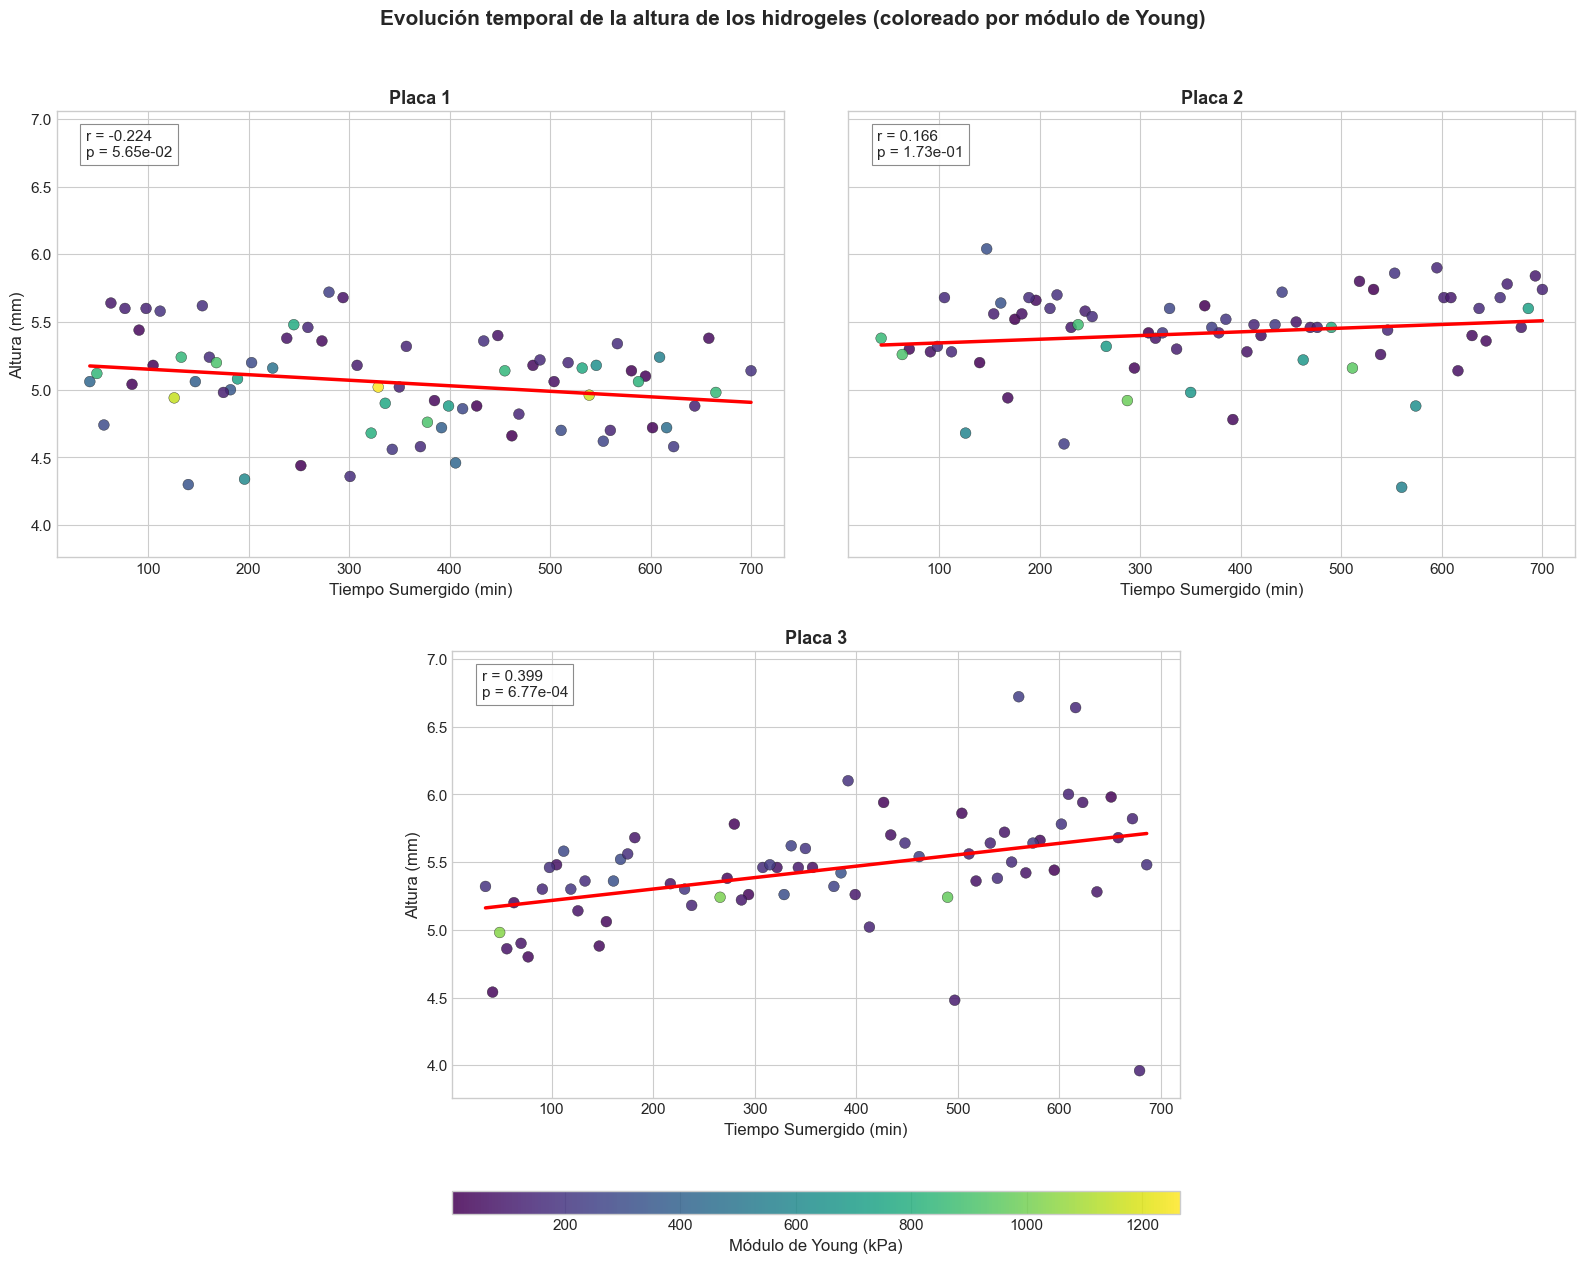

In [18]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_super_limpio['Tiempo Sumergido (min)'] = pd.to_numeric(df_super_limpio['Tiempo Sumergido (min)'], errors='coerce')
df_super_limpio['Altura (mm)'] = pd.to_numeric(df_super_limpio['Altura (mm)'], errors='coerce')
df_super_limpio[col_young] = pd.to_numeric(df_super_limpio[col_young], errors='coerce')

df_plot = df_super_limpio.replace([np.inf, -np.inf], np.nan).dropna(subset=['Tiempo Sumergido (min)', 'Altura (mm)', col_young])

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 13)) 

gs = gridspec.GridSpec(3, 4, height_ratios=[1, 1, 0.05])        

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)

ax3 = fig.add_subplot(gs[1, 1:3], sharey=ax1)

cax_colorbar = fig.add_subplot(gs[2, 1:3]) 

axes = [ax1, ax2, ax3]

plt.setp(ax2.get_yticklabels(), visible=False)

ymin = df_plot['Altura (mm)'].min() * 0.95
ymax = df_plot['Altura (mm)'].max() * 1.05

vmin = df_plot[col_young].min()
vmax = df_plot[col_young].max()

for ax, dia in zip(axes, sorted(df_plot['DIA ESTUDIO'].unique())):

    df_dia = df_plot[df_plot['DIA ESTUDIO'] == dia]

    sc = ax.scatter(
        df_dia['Tiempo Sumergido (min)'],
        df_dia['Altura (mm)'],
        c=df_dia[col_young],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        s=60,
        alpha=0.85,
        edgecolors='k',
        linewidths=0.3
    )

    x = df_dia['Tiempo Sumergido (min)'].values
    y = df_dia['Altura (mm)'].values

    if len(np.unique(x)) > 1 and len(x) > 2:
        coef = np.polyfit(x, y, 1)
        y_pred = np.polyval(coef, x)

        orden = np.argsort(x)

        ax.plot(
            x[orden],
            y_pred[orden],
            color='red',
            linewidth=2.5,
            label='Ajuste lineal'
        )

        r, p = pearsonr(x, y)

        ax.text(
            0.04,
            0.96,
            f'r = {r:.3f}\np = {p:.2e}',
            transform=ax.transAxes,
            va='top',
            fontsize=11,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9)
        )
    else:
        ax.text(
            0.04,
            0.96,
            'Datos insuficientes\npara regresión',
            transform=ax.transAxes,
            va='top',
            fontsize=11,
            color='red',
            bbox=dict(facecolor='white', edgecolor='red', alpha=0.9)
        )

    ax.set_title(f'Placa {int(dia)}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tiempo Sumergido (min)', fontsize=12)

    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', labelsize=11)

axes[0].set_ylabel('Altura (mm)', fontsize=12)
axes[2].set_ylabel('Altura (mm)', fontsize=12)

cbar = fig.colorbar(
    sc,
    cax=cax_colorbar,
    orientation='horizontal'
)

cbar.set_label('Módulo de Young (kPa)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.suptitle(
    'Evolución temporal de la altura de los hidrogeles (coloreado por módulo de Young)',
    fontsize=15,
    fontweight='bold',
    y=0.97
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0)

plt.savefig(
    'Figura_Altura_Tiempo_RF.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

📊 Generando análisis de reproducibilidad unificado para el sistema PEGDA/RF/TEOA...


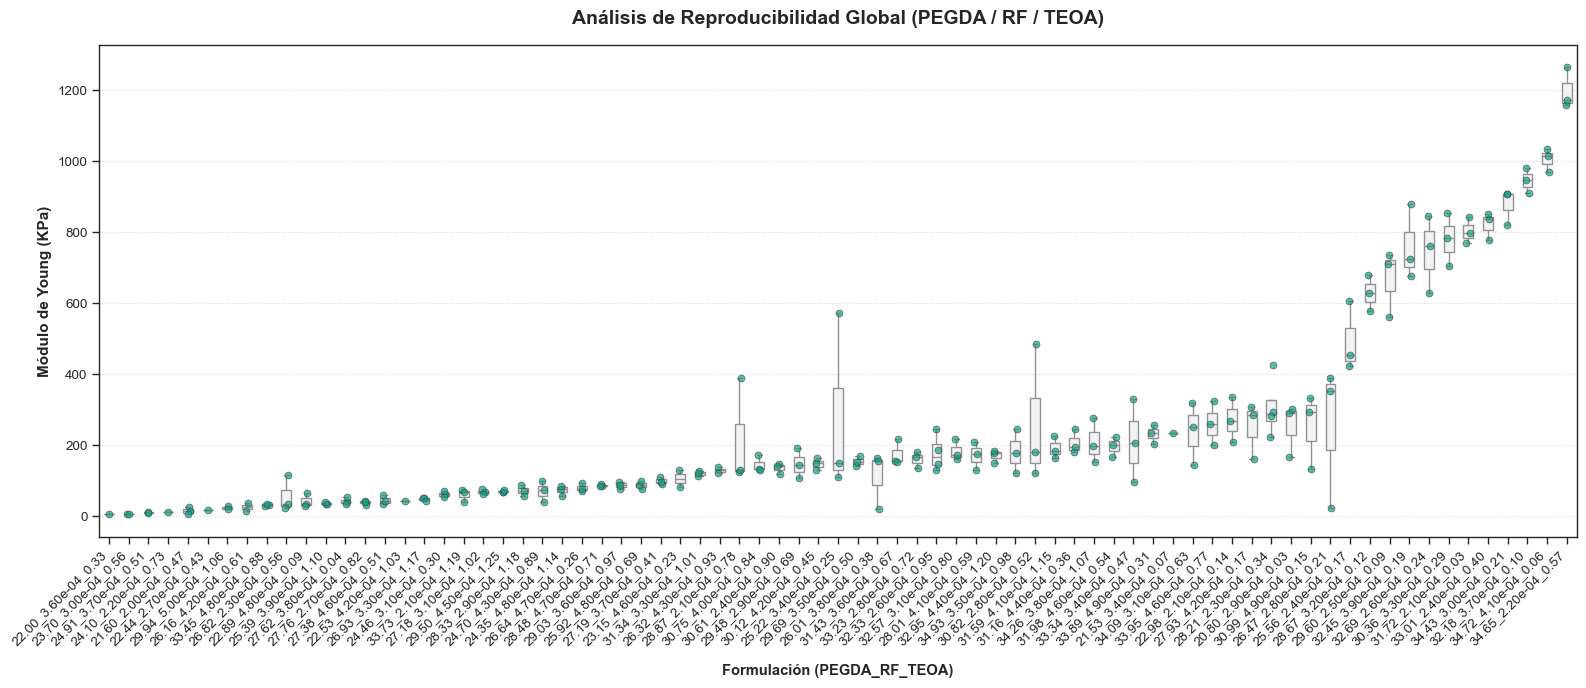


📈 AUDITORÍA DE REPRODUCIBILIDAD
Total de formulaciones distintas ensayadas: 75
CV Medio Global del Laboratorio: 24.81%
- CV Medio Fase 1: Hidrogeles Blandos: 27.16%
- CV Medio Fase 2: Hidrogeles Intermedios: 26.13%
- CV Medio Fase 3: Hidrogeles Rígidos: 21.39%

⚠️ AVISO EXPERIMENTAL:
Tienes 5 formulaciones con 1 sola réplica en tu Excel.
El modelo de Machine Learning las usará perfectamente, pero no entran en el cálculo del CV.


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print(
    "Generando análisis de reproducibilidad unificado para el sistema PEGDA/RF/TEOA..."
)

df_super_limpio["Receta_ID"] = (
    df_super_limpio["PEGDA (%)"].map(lambda x: f"{x:.2f}")
    + "_"
    + df_super_limpio["RF (%)"].map(lambda x: f"{x:.2e}")
    + "_"
    + df_super_limpio["TEOA (%)"].map(lambda x: f"{x:.2f}")
)

orden_recetas = (
    df_super_limpio.groupby("Receta_ID")[col_young].median().sort_values().index
)

grupos_recetas = np.array_split(orden_recetas, 3)
nombres_fases = [
    "Fase 1: Hidrogeles Blandos",
    "Fase 2: Hidrogeles Intermedios",
    "Fase 3: Hidrogeles Rígidos",
]

sns.set_theme(style="ticks", context="paper", font_scale=1.1)

# =====================================================================
# CREACIÓN DE LA GRÁFICA
# =====================================================================
# Usamos un ancho de 16 dado que la notación científica (.2e) alarga las etiquetas del eje X
fig, ax = plt.subplots(figsize=(16, 7))

# A) Boxplot estadístico global
sns.boxplot(
    x="Receta_ID",
    y=col_young,
    data=df_super_limpio,
    order=orden_recetas,
    color="#F2F3F4",
    width=0.5,
    showfliers=False,
    ax=ax,
)

# B) Stripplot
sns.stripplot(
    x="Receta_ID",
    y=col_young,
    data=df_super_limpio,
    order=orden_recetas,
    size=5,
    color="#16A085",
    alpha=0.7,
    jitter=True,
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Análisis de Reproducibilidad Global (PEGDA / RF / TEOA)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Módulo de Young (KPa)", fontweight="bold", fontsize=11)
ax.set_xlabel("Formulación (PEGDA_RF_TEOA)", fontweight="bold", labelpad=12)


ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#BDC3C7")


plt.tight_layout()

plt.savefig(
    "Reproducibilidad_Sistema_TEOA_Unificado.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

📅 Generando análisis completo de Reproducibilidad y Rigidez Inter-Sesión...


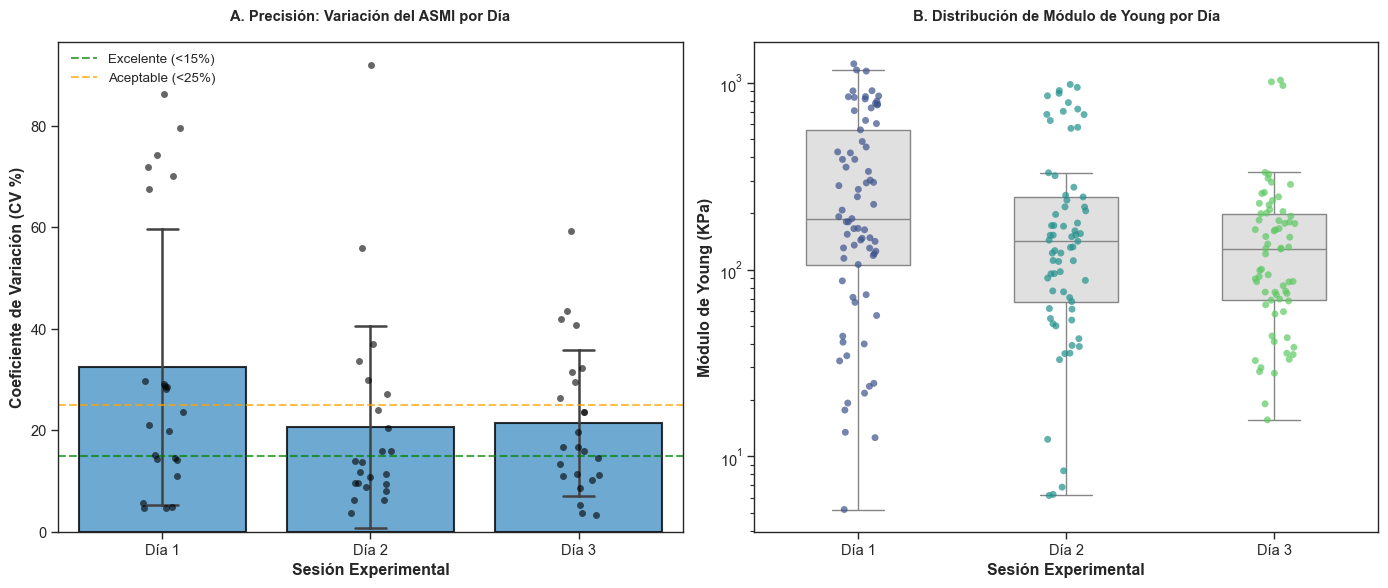


📊 RESUMEN DE VARIABILIDAD INTER-SESIÓN (ASMI)
              CV Medio (%)  Módulo Young Medio (KPa)  Desviación Young (±KPa)  Total Probetas
Etiqueta_Dia                                                                                 
Día 1                32.50                    341.81                   330.56              73
Día 2                20.67                    241.02                   269.36              69
Día 3                21.43                    168.78                   197.58              69

💡 DATO CLAVE: El Módulo de Young promedio más bajo fue de 168.78 KPa, y el más alto de 341.81 KPa.
Recuerda: Si estos números son muy distintos, asegúrate de que no se deba simplemente a que fabricaste recetas distintas cada día.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("📅 Generando análisis completo de Reproducibilidad y Rigidez Inter-Sesión...")

col_sesion = 'DIA ESTUDIO'

if col_sesion not in df_super_limpio.columns:
    print(f"⚠️ ERROR: No encuentro la columna '{col_sesion}'.")
else:
    # 1. PREPARACIÓN DE ETIQUETAS
    df_super_limpio['Etiqueta_Dia'] = 'Día ' + df_super_limpio[col_sesion].astype(str)
    
    # 2. CÁLCULO DE MÉTRICAS (CV por receta y día)
    metricas_sesion = df_super_limpio.groupby(['Etiqueta_Dia', 'Receta_ID'])[col_young].agg(['mean', 'std', 'count']).reset_index()
    metricas_sesion = metricas_sesion[metricas_sesion['count'] > 1].copy()
    metricas_sesion['CV (%)'] = (metricas_sesion['std'] / metricas_sesion['mean']) * 100

    # 3. CREACIÓN DE LA FIGURA DE DOBLE PANEL (NIVEL TESIS Q1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.set_theme(style="ticks", context="paper", font_scale=1.1)

    # ================= PANEL 1: Coeficiente de Variación (Precisión) =================
    sns.barplot(x='Etiqueta_Dia', y='CV (%)', data=metricas_sesion, ax=axes[0],
                color="#3498DB", edgecolor="black", linewidth=1.5, capsize=0.15, errorbar="sd", alpha=0.8)
    sns.stripplot(x='Etiqueta_Dia', y='CV (%)', data=metricas_sesion, ax=axes[0],
                  color="black", size=5, jitter=True, alpha=0.6)
    
    axes[0].axhline(y=15, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Excelente (<15%)')
    axes[0].axhline(y=25, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Aceptable (<25%)')
    
    axes[0].set_title("A. Precisión: Variación del ASMI por Día", fontweight='bold', pad=15)
    axes[0].set_ylabel("Coeficiente de Variación (CV %)", fontweight='bold')
    axes[0].set_xlabel("Sesión Experimental", fontweight='bold')
    axes[0].legend(loc="upper left")
    axes[0].set_ylim(bottom=0)

    # ================= PANEL 2: Módulo de Young Medio (Rigidez Global) =================
    sns.boxplot(x='Etiqueta_Dia', y=col_young, data=df_super_limpio, ax=axes[1],
                color="#E0E0E0", width=0.5, showfliers=False)
    sns.stripplot(x='Etiqueta_Dia', y=col_young, data=df_super_limpio, ax=axes[1],
                  palette="viridis", size=5, jitter=True, alpha=0.7)
    
    axes[1].set_title("B. Distribución de Módulo de Young por Día", fontweight='bold', pad=15)
    axes[1].set_ylabel("Módulo de Young (KPa)", fontweight='bold')
    axes[1].set_xlabel("Sesión Experimental", fontweight='bold')
    
    # Si tienes saltos muy grandes de rigidez y la caja no se ve bien, quita el '#' de la siguiente línea:
    axes[1].set_yscale('log')

    # Guardamos y mostramos
    plt.tight_layout()
    plt.savefig('Analisis_Dias_Completo_RF.png', dpi=600, bbox_inches='tight')
    plt.show()

    # =====================================================================
    # 4. REPORTE ESTADÍSTICO PARA LA TESIS (Incluyendo Modulo de Young)
    # =====================================================================
    print("\n=======================================================")
    print("📊 RESUMEN DE VARIABILIDAD INTER-SESIÓN (ASMI)")
    print("=======================================================")

    # Calculamos CV Medio
    resumen_cv = metricas_sesion.groupby('Etiqueta_Dia')['CV (%)'].agg(['mean']).rename(columns={'mean': 'CV Medio (%)'})
    
    # Calculamos Young Medio directamente de los datos limpios
    resumen_young = df_super_limpio.groupby('Etiqueta_Dia')[col_young].agg(['mean', 'std', 'count'])
    resumen_young.columns = ['Módulo Young Medio (KPa)', 'Desviación Young (±KPa)', 'Total Probetas']

    # Unimos todo en una tabla maestra
    tabla_final = pd.concat([resumen_cv, resumen_young], axis=1)
    
    print(tabla_final.round(2).to_string())

    print("\n=======================================================")
    # Conclusión automática basada en el Módulo de Young Medio
    max_young = tabla_final['Módulo Young Medio (KPa)'].max()
    min_young = tabla_final['Módulo Young Medio (KPa)'].min()
    
    print(f"💡 DATO CLAVE: El Módulo de Young promedio más bajo fue de {min_young:.2f} KPa, y el más alto de {max_young:.2f} KPa.")
    print("Recuerda: Si estos números son muy distintos, asegúrate de que no se deba simplemente a que fabricaste recetas distintas cada día.")

⏱️ Generando análisis de estabilidad intra-día (7 mins por muestra)...


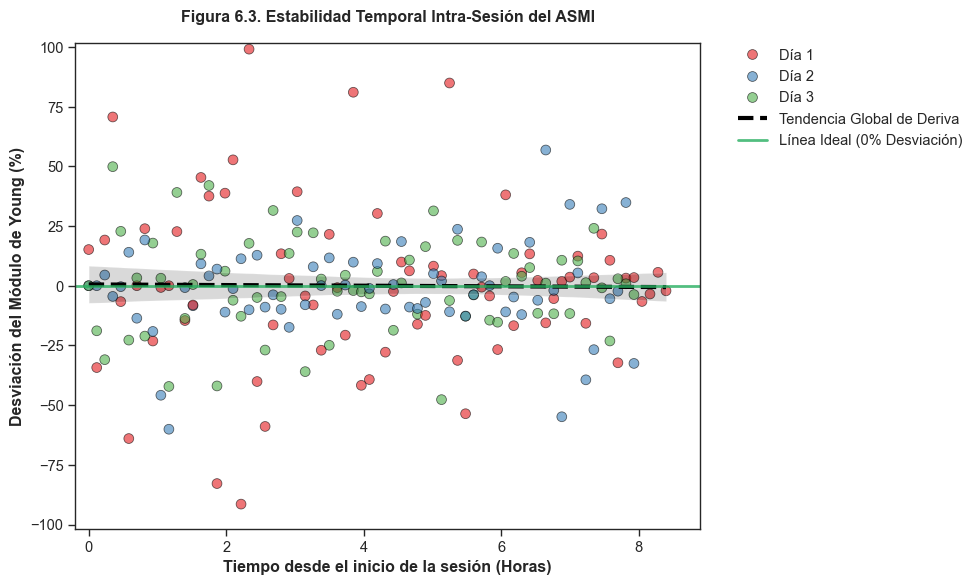


📈 RESULTADOS DE LA PRUEBA DE DERIVA INTRA-SESIÓN
Duración máxima de una sesión: 8.40 horas.
Pendiente de deriva: -0.132% de variación por cada HORA de uso continuo.
Valor p de significancia: 0.8628

💡 CONCLUSIÓN CIENTÍFICA PARA LA DEFENSA:
✅ 'El análisis demostró que el ASMI es estable en sesiones de alto rendimiento. La deriva instrumental observada fue de apenas -0.132% por hora (p = 0.8628), descartando problemas de fatiga del indentador o deshidratación severa de las placas de 96 pocillos durante las 8.4 horas que dura cada sesión experimental.'


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import linregress

print("Generando análisis de estabilidad intra-día (7 mins por muestra)...")

# =====================================================================
# CHEQUEOS DE SEGURIDAD PREVIOS
# =====================================================================
col_sesion = 'DIA ESTUDIO'

if 'Etiqueta_Dia' not in df_super_limpio.columns:
    df_super_limpio['Etiqueta_Dia'] = 'Día ' + df_super_limpio[col_sesion].astype(str)

df_deriva = df_super_limpio.copy()

# =====================================================================
# CREACIÓN DEL EJE DE TIEMPO INTRA-DÍA
# =====================================================================
df_deriva['Orden_Intradia'] = df_deriva.groupby(col_sesion).cumcount()
df_deriva['Tiempo_Horas'] = (df_deriva['Orden_Intradia'] * 7) / 60

# =====================================================================
# NORMALIZACIÓN
# =====================================================================
medias_esperadas = df_deriva.groupby('Receta_ID')[col_young].transform('mean')
df_deriva['Desviacion_Relativa (%)'] = ((df_deriva[col_young] - medias_esperadas) / medias_esperadas) * 100

# Limpiamos NaNs o infinitos que harían fallar a la regresión lineal
df_deriva = df_deriva.replace([np.inf, -np.inf], np.nan).dropna(subset=['Tiempo_Horas', 'Desviacion_Relativa (%)'])

# =====================================================================
# DIBUJO DE LA GRÁFICA (Estabilidad Intra-Sesión)
# =====================================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Dibujamos los puntos (¡SIN el atributo label para evitar el error!)
sns.scatterplot(
    x='Tiempo_Horas', 
    y='Desviacion_Relativa (%)', 
    hue='Etiqueta_Dia',      
    data=df_deriva,
    palette='Set1',          
    alpha=0.6,
    edgecolor="black",
    s=50
)

# Línea de tendencia global (roja, gruesa)
sns.regplot(
    x='Tiempo_Horas', 
    y='Desviacion_Relativa (%)', 
    data=df_deriva,
    scatter=False,           
    color="black",           
    line_kws={'linewidth': 3, 'linestyle': '--'},
    label='Tendencia Global de Deriva'
)

# Línea del 0% (Medición ideal)
plt.axhline(0, color='#27AE60', linewidth=2, linestyle='-', alpha=0.8, label='Línea Ideal (0% Desviación)')

# Estética
plt.title("Figura 6.3. Estabilidad Temporal Intra-Sesión del ASMI", fontweight='bold', pad=15)
plt.xlabel("Tiempo desde el inicio de la sesión (Horas)", fontweight='bold')
plt.ylabel("Desviación del Módulo de Young (%)", fontweight='bold')

# Leyenda para sacarla fuera del gráfico y que no tape los puntos
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Límites de los ejes con protección matemática
if len(df_deriva) > 0:
    limite_y = df_deriva['Desviacion_Relativa (%)'].quantile(0.98) 
    plt.ylim(-abs(limite_y)*1.5, abs(limite_y)*1.5) # Absoluto para evitar problemas si es negativo
    plt.xlim(-0.2, df_deriva['Tiempo_Horas'].max() + 0.5) 

plt.tight_layout()
plt.savefig('Figura_6_3_Deriva_Intradia_RF.png', dpi=600, bbox_inches='tight')
plt.show()

# =====================================================================
# 4. AUDITORÍA MATEMÁTICA
# =====================================================================
if len(df_deriva) > 1:
    slope, intercept, r_value, p_value, std_err = linregress(df_deriva['Tiempo_Horas'], df_deriva['Desviacion_Relativa (%)'])

    print("\n=======================================================")
    print("📈 RESULTADOS DE LA PRUEBA DE DERIVA INTRA-SESIÓN")
    print("=======================================================")
    print(f"Duración máxima de una sesión: {df_deriva['Tiempo_Horas'].max():.2f} horas.")
    print(f"Pendiente de deriva: {slope:.3f}% de variación por cada HORA de uso continuo.")
    print(f"Valor p de significancia: {p_value:.4f}")

    print("\n💡 CONCLUSIÓN CIENTÍFICA PARA LA DEFENSA:")
    if p_value > 0.05 or abs(slope) < 1.0:
        print(f"✅ 'El análisis demostró que el ASMI es estable en sesiones de alto rendimiento. La deriva instrumental observada fue de apenas {slope:.3f}% por hora (p = {p_value:.4f}), descartando problemas de fatiga del indentador o deshidratación severa de las placas de 96 pocillos durante las {df_deriva['Tiempo_Horas'].max():.1f} horas que dura cada sesión experimental.'")
    else:
        print(f"⚠️ 'Se detectó una leve tendencia a la deriva térmica/deshidratación de {slope:.3f}% por hora. Esto significa que las muestras medidas al final tienden a dar valores ligeramente distintos.'")
else:
    print("⚠️ No hay suficientes datos limpios para calcular la deriva.")

🚀 Generando análisis de Productividad de la Librería Completa (288 muestras / 3 Placas)...


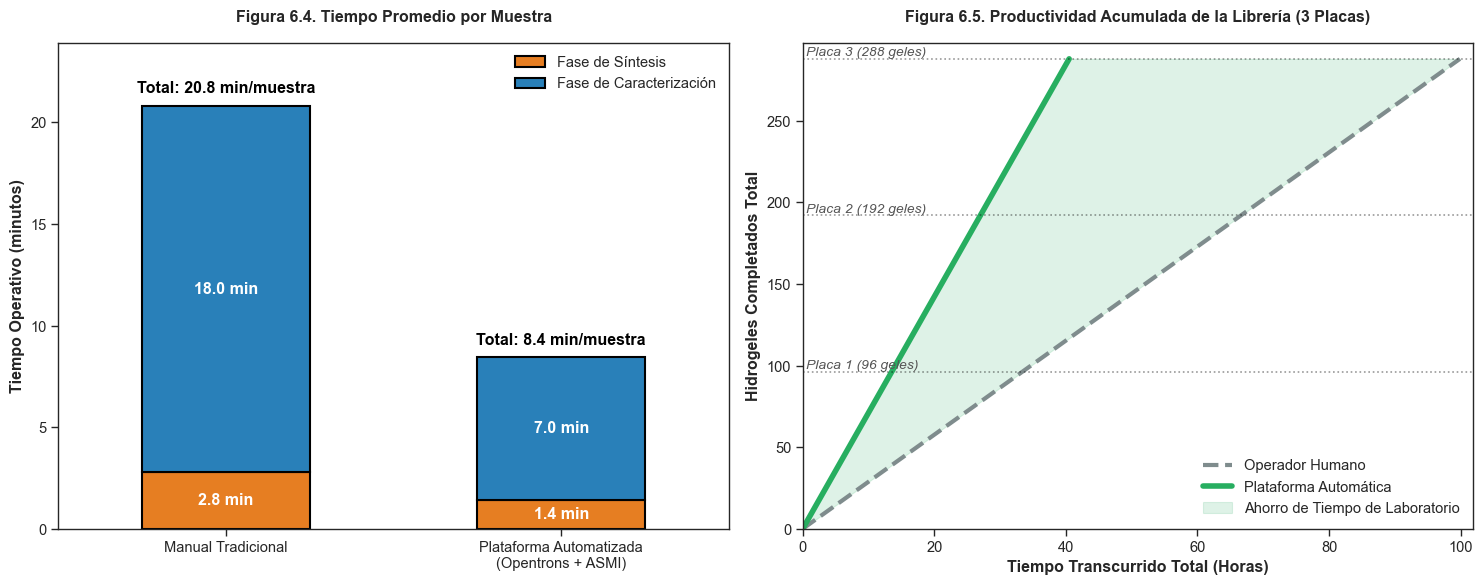


 📊 DATOS FINALES UNIFICADOS PARA LA DEFENSA DE TU TESIS
📌 CONTROL DE CALIDAD DE LA LIBRERÍA (DATA CLEANING):
- Volumen inicial de la librería: 229 probetas ensayadas.
- Fallos críticos de lectura (No gelificación o Módulo de Young inferior al límite de detección del ASMI): 1 muestras.
- Respuestas mecánicas aberrantes filtradas (Filtro robusto MAD): 17 muestras.
- Datos puros exportados a Machine Learning: 211 (92.1%)

📌 RENDIMIENTO OPERATIVO REAL:
- Rendimiento de caracterización del ASMI: 20.7 muestras/hora.
- Tiempo estimado para procesar las 3 placas a mano: 99.9 horas.
- Tiempo de ejecución con la plataforma: 40.5 horas.
🔥 AHORRO NETO: 59.4 horas de trabajo de laboratorio.
📈 FACTOR DE ACELERACIÓN: Reducción del 59.5% del tiempo de screening.

💡 EL ARGUMENTO MAESTRO PARA EL TRIBUNAL:
👉 'El proceso de filtrado de datos no solo aisló ruidos estadísticos (Filtro MAD), sino que actuó como un indicador biocompatible de viabilidad. Un 1 de las muestras (0.4%) fueron descartadas automáti

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Generando análisis de Productividad de la Librería Completa (288 muestras / 3 Placas)...")

# =====================================================================
# 1. CONFIGURACIÓN BASADA EN DATOS REALES
# =====================================================================
# El Excel contiene el screening totalizado de las 3 placas
muestras_totales = 288  # 3 placas x 96 pocillos
n_placas = 3

# --- Tiempos Automatizados (Validados a 7 min/muestra en caract.) ---
t_sintesis_auto_total = (120 + 10 + 8) * n_placas  # Tiempo total para las 3 placas (min)
t_caract_auto_total = muestras_totales * 7.0       # ASMI total (min)

# --- Tiempos Manuales Estimados (Para las 288 muestras) ---
t_sintesis_manual_total = (240 + 10 + 20) * n_placas # Síntesis manual (min)
t_caract_manual_total = muestras_totales * 18.0      # Caracterización manual (min)

# Pasamos a "Tiempo promedio por muestra" para la gráfica de barras
t_sintesis_auto_m = t_sintesis_auto_total / muestras_totales
t_caract_auto_m = t_caract_auto_total / muestras_totales
t_total_auto_m = t_sintesis_auto_m + t_caract_auto_m

t_sintesis_manual_m = t_sintesis_manual_total / muestras_totales
t_caract_manual_m = t_caract_manual_total / muestras_totales
t_total_manual_m = t_sintesis_manual_m + t_caract_manual_m

# =====================================================================
# 2. PREPARACIÓN DE DATOS PARA LAS GRÁFICAS
# =====================================================================
df_tiempos = pd.DataFrame({
    'Flujo de Trabajo': ['Manual Tradicional', 'Plataforma Automatizada\n(Opentrons + ASMI)'],
    'Fase de Síntesis': [t_sintesis_manual_m, t_sintesis_auto_m],
    'Fase de Caracterización': [t_caract_manual_m, t_caract_auto_m]
})
df_tiempos.set_index('Flujo de Trabajo', inplace=True)

# Vectores de productividad (Acumulado de horas a lo largo de las 288 muestras)
horas_manual = (np.arange(0, muestras_totales + 1) * t_total_manual_m) / 60
horas_auto = (np.arange(0, muestras_totales + 1) * t_total_auto_m) / 60

# =====================================================================
# 3. DIBUJO DEL DOBLE PANEL
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# --------- FIGURA : BARRAS APILADAS (Izquierda) ---------
colores = ['#E67E22', '#2980B9']

df_tiempos.plot(
    kind='bar', stacked=True, ax=axes[0], color=colores, 
    edgecolor='black', linewidth=1.5, width=0.5
)

for i, (idx, row) in enumerate(df_tiempos.iterrows()):
    axes[0].text(i, row['Fase de Síntesis'] / 2, f"{row['Fase de Síntesis']:.1f} min", 
                 ha='center', va='center', color='white', fontweight='bold')
    
    axes[0].text(i, row['Fase de Síntesis'] + (row['Fase de Caracterización'] / 2), 
                 f"{row['Fase de Caracterización']:.1f} min", 
                 ha='center', va='center', color='white', fontweight='bold')
    
    total = row['Fase de Síntesis'] + row['Fase de Caracterización']
    axes[0].text(i, total + 0.5, f"Total: {total:.1f} min/muestra", 
                 ha='center', va='bottom', color='black', fontweight='bold')

axes[0].set_title("Figura 6.4. Tiempo Promedio por Muestra", fontweight='bold', pad=15)
axes[0].set_ylabel("Tiempo Operativo (minutos)", fontweight='bold')
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0) 
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, t_total_manual_m * 1.15)

# --------- FIGURA : CURVA DE PRODUCTIVIDAD (Derecha) ---------
axes[1].plot(horas_manual, np.arange(0, muestras_totales + 1), 
             color='#7F8C8D', linewidth=3, linestyle='--', label='Operador Humano')
axes[1].plot(horas_auto, np.arange(0, muestras_totales + 1), 
             color='#27AE60', linewidth=4, label='Plataforma Automática')

# Sombreado del océano de horas ahorradas
axes[1].fill_betweenx(np.arange(0, muestras_totales + 1), horas_auto, horas_manual, 
                      color='#27AE60', alpha=0.15, label='Ahorro de Tiempo de Laboratorio')

# Líneas guía para las 3 placas de 96
for p in range(1, n_placas + 1):
    y_val = p * 96
    axes[1].axhline(y=y_val, color='black', linestyle=':', alpha=0.4)
    axes[1].text(0.5, y_val + 2, f'Placa {p} ({y_val} geles)', fontsize=10, style='italic', color='#555555')

axes[1].set_title("Figura 6.5. Productividad Acumulada de la Librería (3 Placas)", fontweight='bold', pad=15)
axes[1].set_ylabel("Hidrogeles Completados Total", fontweight='bold')
axes[1].set_xlabel("Tiempo Transcurrido Total (Horas)", fontweight='bold')
axes[1].legend(loc="lower right")

axes[1].set_xlim(0, max(horas_manual) + 2)
axes[1].set_ylim(0, muestras_totales + 10)

plt.tight_layout()
plt.savefig('Productividad_Real_Libreria_Completa.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================================
# 4. REPORTE FILTRADO CON DATOS REALES DE BASE DE DATOS
# =====================================================================
# Usamos el tiempo real de tu script anterior para el cálculo de rendimiento exacto
tiempo_total_horas_real = (df_inicial['Tiempo Sumergido (min)'].max() - df_inicial['Tiempo Sumergido (min)'].min()) / 60
rendimiento_hora_muestras = len(df_inicial) / tiempo_total_horas_real if tiempo_total_horas_real > 0 else 0

h_manual = (t_total_manual_m * muestras_totales) / 60
h_auto = (t_total_auto_m * muestras_totales) / 60
ahorro = h_manual - h_auto
mejora_pct = ((h_manual - h_auto) / h_manual) * 100

print("\n" + "="*65)
print(" 📊 DATOS FINALES UNIFICADOS PARA LA DEFENSA DE TU TESIS")
print("="*65)
print("📌 CONTROL DE CALIDAD DE LA LIBRERÍA (DATA CLEANING):")
print(f"- Volumen inicial de la librería: {len(df_inicial)} probetas ensayadas.")
print(f"- Fallos críticos de lectura (No gelificación o Módulo de Young inferior al límite de detección del ASMI): {len(df_inicial) - len(df_medible)} muestras.")
print(f"- Respuestas mecánicas aberrantes filtradas (Filtro robusto MAD): {len(df_medible) - len(df_super_limpio)} muestras.")
print(f"- Datos puros exportados a Machine Learning: {len(df_super_limpio)} ({(len(df_super_limpio)/len(df_inicial))*100:.1f}%)")

print("\n📌 RENDIMIENTO OPERATIVO REAL:")
print(f"- Rendimiento de caracterización del ASMI: {rendimiento_hora_muestras:.1f} muestras/hora.")
print(f"- Tiempo estimado para procesar las 3 placas a mano: {h_manual:.1f} horas.")
print(f"- Tiempo de ejecución con la plataforma: {h_auto:.1f} horas.")
print(f"🔥 AHORRO NETO: {ahorro:.1f} horas de trabajo de laboratorio.")
print(f"📈 FACTOR DE ACELERACIÓN: Reducción del {mejora_pct:.1f}% del tiempo de screening.")

🔮 Generando Superficie 3D: PEGDA vs Ratio TEOA/RF -> Módulo de Young...


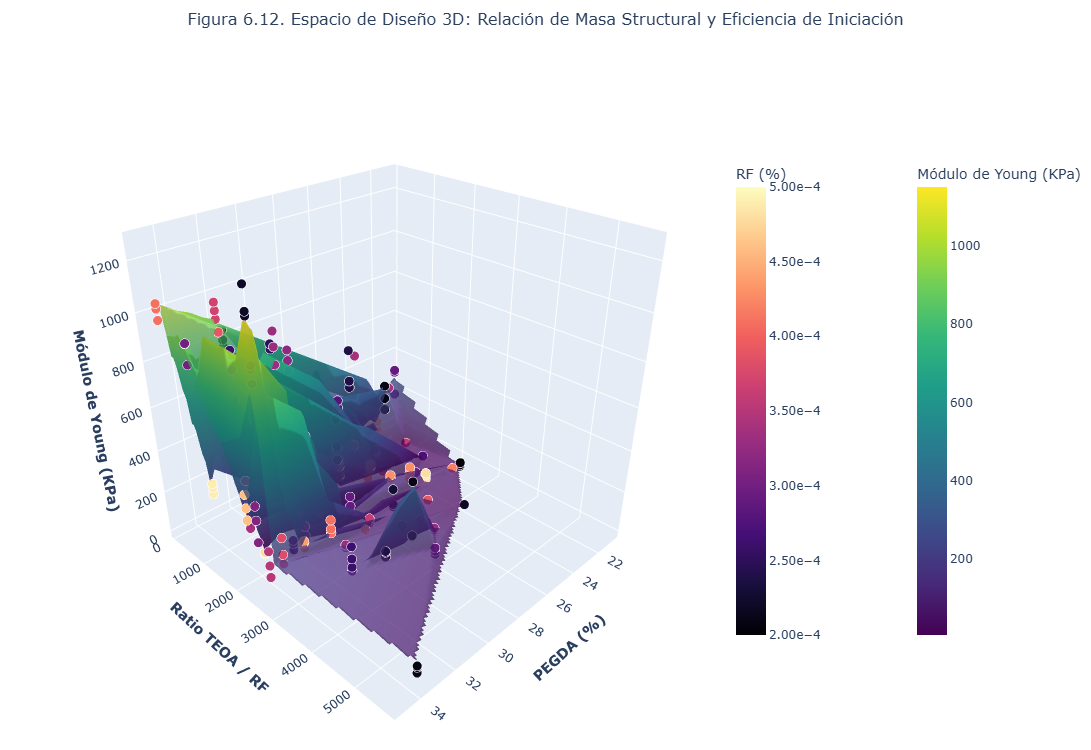

✨ Gráfica interactiva generada y guardada como 'Figura_6_12_Espacio_Redox_3D.html'.


In [14]:
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import plotly.graph_objects as go

print("Generando Superficie 3D: PEGDA vs Ratio TEOA/RF -> Módulo de Young...")

# =====================================================================
# 1. CÁLCULO DE LAS VARIABLES QUÍMICAS
# =====================================================================
df_super_limpio['Polimero_Total (%)'] = df_super_limpio['PEGDA (%)']
df_super_limpio['Ratio_TEOA_RF'] = df_super_limpio['TEOA (%)'] / df_super_limpio['RF (%)']

x_pegda = df_super_limpio['Polimero_Total (%)']
y_ratio = df_super_limpio['Ratio_TEOA_RF']
z_young = df_super_limpio[col_young]
c_rf = df_super_limpio['RF (%)'] 

# =====================================================================
# 2. INTERPOLACIÓN DE LA MALLA TRIDIMENSIONAL
# =====================================================================
xi = np.linspace(x_pegda.min(), x_pegda.max(), 100)
yi = np.linspace(y_ratio.min(), y_ratio.max(), 100)
xi_mesh, yi_mesh = np.meshgrid(xi, yi)

# Interpolamos linealmente los valores del Módulo de Young sobre la malla X-Y
zi_mesh = griddata((x_pegda, y_ratio), z_young, (xi_mesh, yi_mesh), method='linear')

# =====================================================================
# 3. CONSTRUCCIÓN DE LA FIGURA 3D (PLOTLY)
# =====================================================================
fig = go.Figure()

# Trazo 1: Superficie de Tendencia (Módulo de Young)
fig.add_trace(go.Surface(
    x=xi_mesh, y=yi_mesh, z=zi_mesh,
    colorscale='Viridis', 
    opacity=0.75, 
    name='Superficie de Tendencia',
    colorbar=dict(
        title=dict(text='Módulo de Young (KPa)', side='top'),
        x=1.15,        
        len=0.7
    )
))

# Trazo 2: Puntos Experimentales Reales
fig.add_trace(go.Scatter3d(
    x=x_pegda, y=y_ratio, z=z_young,
    mode='markers',
    marker=dict(
        size=5.5,
        color=c_rf, 
        colorscale='Magma', 
        colorbar=dict(
            title=dict(text='RF (%)', side='top'), 
            x=0.92,    # Posicionado estratégicamente a la izquierda de la barra del Módulo
            len=0.7,
            tickformat=".2e"  # Fuerza la notación científica para la Riboflavina (e.g., 2.50e-4)
        ),
        line=dict(color='white', width=1)
    ),
    name='Probetas Reales',
    hovertemplate="<b>PEGDA:</b> %{x:.1f}%<br>" +
                  "<b>Ratio TEOA/RF:</b> %{y:.2f}<br>" +
                  "<b>Módulo Young:</b> %{z:.1f} KPa<br>" +
                  "<b>RF pura:</b> %{marker.color:.2e}%<extra></extra>"
))

# =====================================================================
# 4. CONFIGURACIÓN DEL ESPACIO DE DISEÑO Y EJES
# =====================================================================
fig.update_layout(
    title=dict(
        text='Figura 6.12. Espacio de Diseño 3D: Relación de Masa Structural y Eficiencia de Iniciación', 
        font=dict(size=16), 
        x=0.5
    ),
    scene=dict(
        xaxis_title=dict(text='PEGDA (%)', font=dict(weight='bold')),
        yaxis_title=dict(text='Ratio TEOA / RF', font=dict(weight='bold')),
        zaxis_title=dict(text='Módulo de Young (KPa)', font=dict(weight='bold')),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2) # Ángulo de cámara isométrico óptimo para ver el relieve
        )
    ),
    width=950, 
    height=750,
    margin=dict(l=0, r=50, b=0, t=50) # Maximiza el tamaño del gráfico dentro del contenedor
)

# Renderizar y exportar en HTML interactivo
fig.show()
fig.write_html("Figura_6_12_Espacio_Redox_3D.html")
print("Gráfica interactiva generada y guardada como 'Figura_6_12_Espacio_Redox_3D.html'.")

🗺️ Re-generando Gráfica 1: Isolíneas sin etiquetas de texto...


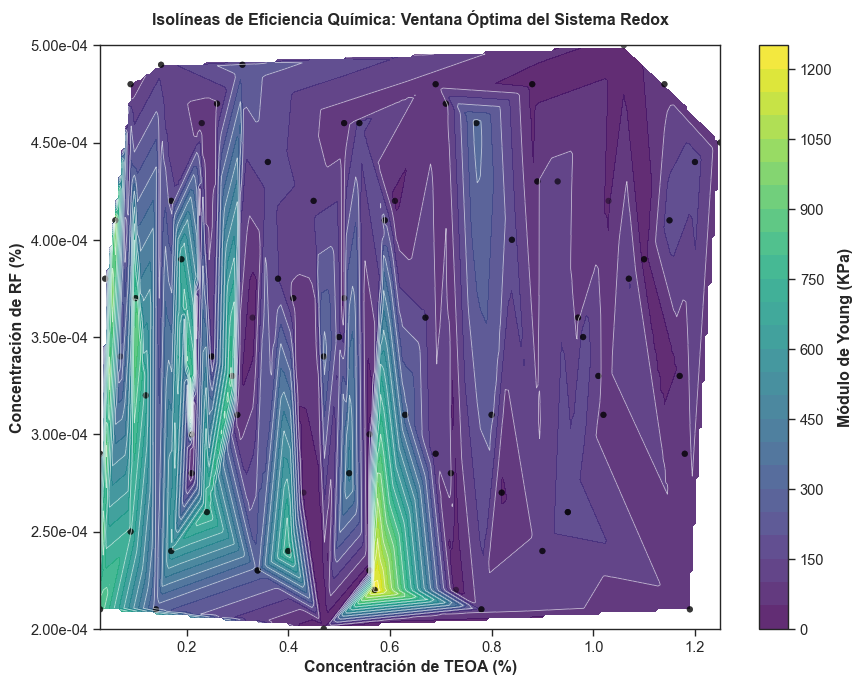

👁️ Generando Proyección 2D desde arriba: PEGDA vs Ratio TEOA/RF...


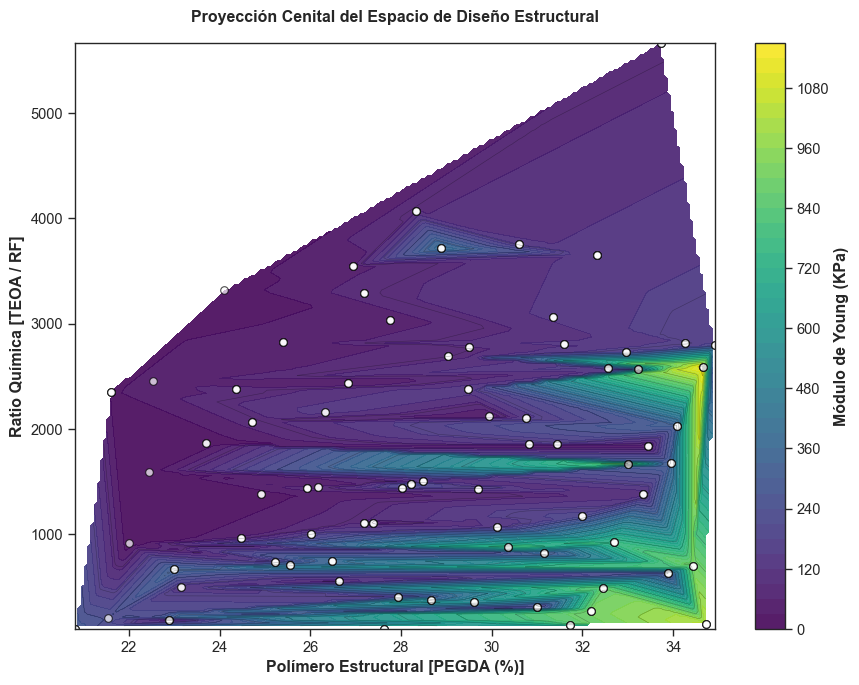

✨ Visualizaciones listas. Se han guardado 'Grafica_1_Isolineas_Limpio.png' y 'Grafica_Espacio_Diseño_2D_Cenital.png'.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

df_super_limpio['Polimero_Total (%)'] = df_super_limpio['PEGDA (%)']
df_super_limpio['Ratio_TEOA_RF'] = df_super_limpio['TEOA (%)'] / df_super_limpio['RF (%)']

x_pegda = df_super_limpio['Polimero_Total (%)']
y_ratio = df_super_limpio['Ratio_TEOA_RF']
z_young = df_super_limpio[col_young]

# =====================================================================
# REFINAMIENTO GRÁFICA 1: ISOLÍNEAS LIMPIAS (Sin números en el medio)
# =====================================================================
print("Re-generando Gráfica 1: Isolíneas sin etiquetas de texto...")

xi_2d = np.linspace(df_super_limpio['TEOA (%)'].min(), df_super_limpio['TEOA (%)'].max(), 200)
yi_2d = np.linspace(df_super_limpio['RF (%)'].min(), df_super_limpio['RF (%)'].max(), 200)
xi_mesh_2d, yi_mesh_2d = np.meshgrid(xi_2d, yi_2d)

zi_mesh_2d = griddata(
    (df_super_limpio['TEOA (%)'], df_super_limpio['RF (%)']), 
    df_super_limpio[col_young], 
    (xi_mesh_2d, yi_mesh_2d), 
    method='linear'
)

plt.figure(figsize=(9, 7))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Zonas térmicas de fondo
contour_filled = plt.contourf(xi_mesh_2d, yi_mesh_2d, zi_mesh_2d, levels=25, cmap='viridis', alpha=0.85)
cbar = plt.colorbar(contour_filled)
cbar.set_label('Módulo de Young (KPa)', fontweight='bold')

# Líneas de nivel puras (Se elimina plt.clabel para limpiar el centro)
plt.contour(xi_mesh_2d, yi_mesh_2d, zi_mesh_2d, levels=12, colors='white', linewidths=0.6, alpha=0.7)

# Probetas reales ensayadas
plt.scatter(df_super_limpio['TEOA (%)'], df_super_limpio['RF (%)'], color='black', s=20, alpha=0.4, edgecolor='none')

plt.title("Isolíneas de Eficiencia Química: Ventana Óptima del Sistema Redox", fontweight='bold', pad=15)
plt.xlabel("Concentración de TEOA (%)", fontweight='bold')
plt.ylabel("Concentración de RF (%)", fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))

plt.tight_layout()
plt.savefig('Grafica_1_Isolineas_Limpio.png', dpi=300, bbox_inches='tight')
plt.show()


# =====================================================================
# NUEVA GRÁFICA: PROYECCIÓN 2D SUPERIOR DEL ESPACIO DE DISEÑO (Vista Cenital)
# =====================================================================
print("Generando Proyección 2D desde arriba: PEGDA vs Ratio TEOA/RF...")

# Generamos la malla específica para los nuevos ejes
xi_3d_2d = np.linspace(x_pegda.min(), x_pegda.max(), 200)
yi_3d_2d = np.linspace(y_ratio.min(), y_ratio.max(), 200)
xi_mesh_3d_2d, yi_mesh_3d_2d = np.meshgrid(xi_3d_2d, yi_3d_2d)

# Interpolación del relieve mecánico
zi_mesh_3d_2d = griddata((x_pegda, y_ratio), z_young, (xi_mesh_3d_2d, yi_mesh_3d_2d), method='linear')

plt.figure(figsize=(9, 7))

# Mapa térmico continuo (Simula mirar la superficie 3D perfectamente desde arriba)
projection = plt.contourf(xi_mesh_3d_2d, yi_mesh_3d_2d, zi_mesh_3d_2d, levels=40, cmap='viridis', alpha=0.9)
cbar_proj = plt.colorbar(projection)
cbar_proj.set_label('Módulo de Young (KPa)', fontweight='bold')

# Líneas de contorno muy tenues para acentuar los cambios de nivel geométricos
plt.contour(xi_mesh_3d_2d, yi_mesh_3d_2d, zi_mesh_3d_2d, levels=15, colors='black', linewidths=0.4, alpha=0.3)

# Superponemos las probetas del espacio real
plt.scatter(x_pegda, y_ratio, color='white', s=30, alpha=0.7, edgecolor='black', linewidth=0.8, label='Muestras')

plt.title("Proyección Cenital del Espacio de Diseño Estructural", fontweight='bold', pad=15)
plt.xlabel("Polímero Estructural [PEGDA (%)]", fontweight='bold')
plt.ylabel("Ratio Química [TEOA / RF]", fontweight='bold')

plt.tight_layout()
plt.savefig('Grafica_Espacio_Diseño_2D_Cenital.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizaciones listas. Se han guardado 'Grafica_1_Isolineas_Limpio.png' y 'Grafica_Espacio_Diseño_2D_Cenital.png'.")